# m-out-of-n Bootstrap Scaling Experiment

Does scaling the m-out-of-n bootstrap correction by $\sqrt{m/N}$ fix overcorrection?

In [1]:
%run _dev_setup.py

🔁 Autoreload is ON (IPython detected).
✅ Using winners_curse from: /Users/iamsikun/Desktop/research/winners-curse/src/winners_curse


In [2]:
import pickle
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'serif'
tick_label_size = 12
axis_label_size = 14
legend_label_size = 12
title_size = 16

## Load Results

In [3]:
result_dir = '../results/ab_test_moon_scaling_20260326_101840/'

with open(f'{result_dir}/results.pkl', 'rb') as f:
    results = pickle.load(f)

with open(f'{result_dir}/config.json', 'r') as f:
    config = json.load(f)

In [4]:
# Estimator display names
estimator_keys = [
    'nc',
    'standard_bootstrap',
    'moon_080_unscaled',
    'moon_080_scaled',
    'moon_095_unscaled',
    'moon_095_scaled',
]

estimator_labels = {
    'nc': 'No Correction',
    'standard_bootstrap': 'Standard Bootstrap',
    'moon_080_unscaled': r'm-out-of-n ($\gamma$=0.8)',
    'moon_080_scaled': r'm-out-of-n ($\gamma$=0.8, scaled)',
    'moon_095_unscaled': r'm-out-of-n ($\gamma$=0.95)',
    'moon_095_scaled': r'm-out-of-n ($\gamma$=0.95, scaled)',
}

sample_sizes = sorted(set(k[0] for k in results.keys()))
tau_tuples = sorted(set(k[1] for k in results.keys()))
print(f'Sample sizes: {sample_sizes}')
print(f'Tau tuples: {tau_tuples}')

Sample sizes: [500, 1000, 2500, 5000]
Tau tuples: [(1, 1.005), (1, 1.01), (1, 1.02), (1, 1.05)]


## Summary Statistics Table

Mean bias (Winner's Curse) across all cells.

In [5]:
rows = []
for (n, tau), res in sorted(results.items()):
    delta_tau = tau[1] - tau[0]
    row = {'N': n, 'delta_tau': delta_tau}
    for est in estimator_keys:
        wc_arr = res[f'{est}_wc_arr']
        row[f'{est}_mean_bias'] = wc_arr.mean()
        row[f'{est}_rmse'] = np.sqrt((wc_arr ** 2).mean())
    rows.append(row)

df = pd.DataFrame(rows)

# Display mean bias
bias_cols = {f'{e}_mean_bias': estimator_labels[e] for e in estimator_keys}
bias_df = df[['N', 'delta_tau'] + list(bias_cols.keys())].rename(columns=bias_cols)
bias_df = bias_df.set_index(['N', 'delta_tau']).round(4)
bias_df.style.background_gradient(cmap='RdYlGn_r', axis=None)

In [6]:
# Display RMSE
rmse_cols = {f'{e}_rmse': estimator_labels[e] for e in estimator_keys}
rmse_df = df[['N', 'delta_tau'] + list(rmse_cols.keys())].rename(columns=rmse_cols)
rmse_df = rmse_df.set_index(['N', 'delta_tau']).round(4)
rmse_df.style.background_gradient(cmap='YlOrRd', axis=None)

## Mean Bias by SNR (one panel per sample size)

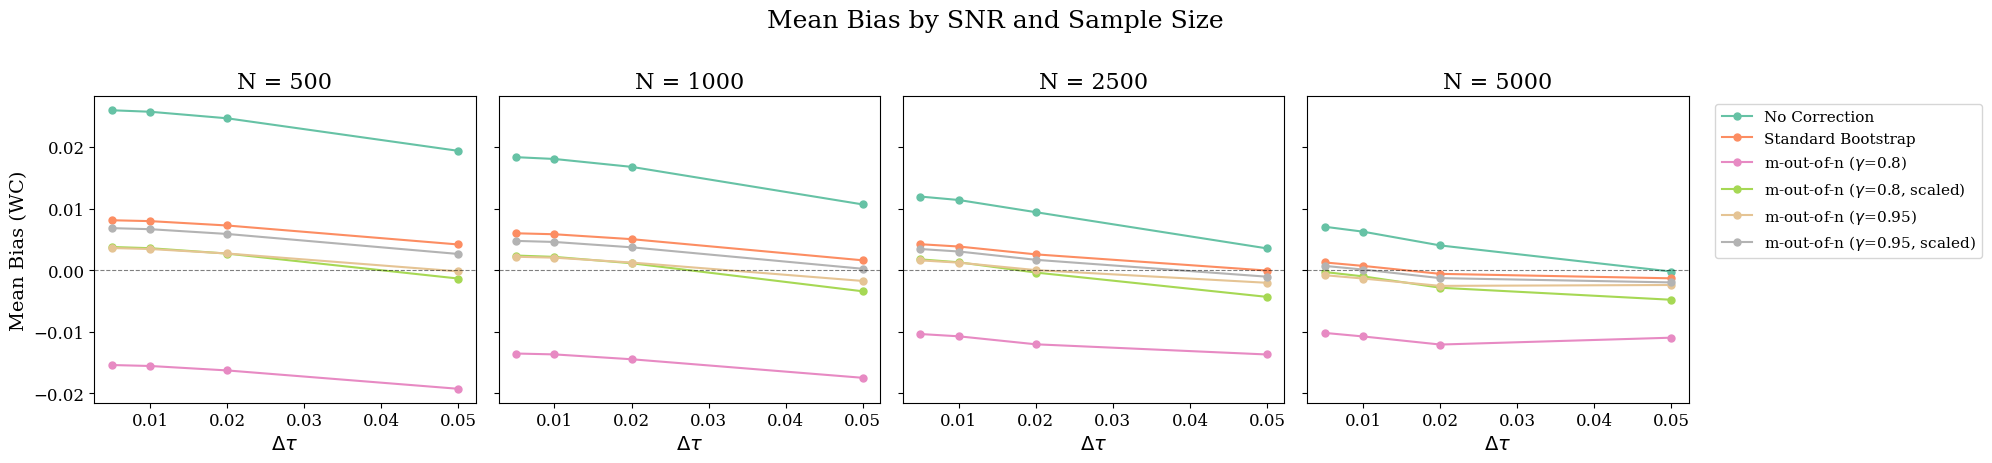

In [7]:
fig, axes = plt.subplots(1, len(sample_sizes), figsize=(5 * len(sample_sizes), 4.5), sharey=True)

colors = plt.cm.Set2(np.linspace(0, 1, len(estimator_keys)))

for idx, n in enumerate(sample_sizes):
    ax = axes[idx]
    for est_idx, est in enumerate(estimator_keys):
        deltas = []
        biases = []
        for tau in tau_tuples:
            res = results[(n, tau)]
            deltas.append(tau[1] - tau[0])
            biases.append(res[f'{est}_wc_arr'].mean())
        ax.plot(deltas, biases, 'o-', label=estimator_labels[est], color=colors[est_idx], markersize=5)
    
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_title(f'N = {n}', fontsize=title_size)
    ax.set_xlabel(r'$\Delta\tau$', fontsize=axis_label_size)
    if idx == 0:
        ax.set_ylabel('Mean Bias (WC)', fontsize=axis_label_size)
    ax.tick_params(labelsize=tick_label_size)

axes[-1].legend(fontsize=legend_label_size - 1, bbox_to_anchor=(1.05, 1), loc='upper left')
fig.suptitle('Mean Bias by SNR and Sample Size', fontsize=title_size + 2, y=1.02)
fig.tight_layout()
plt.show()

## Mean Bias by Sample Size (one panel per SNR)

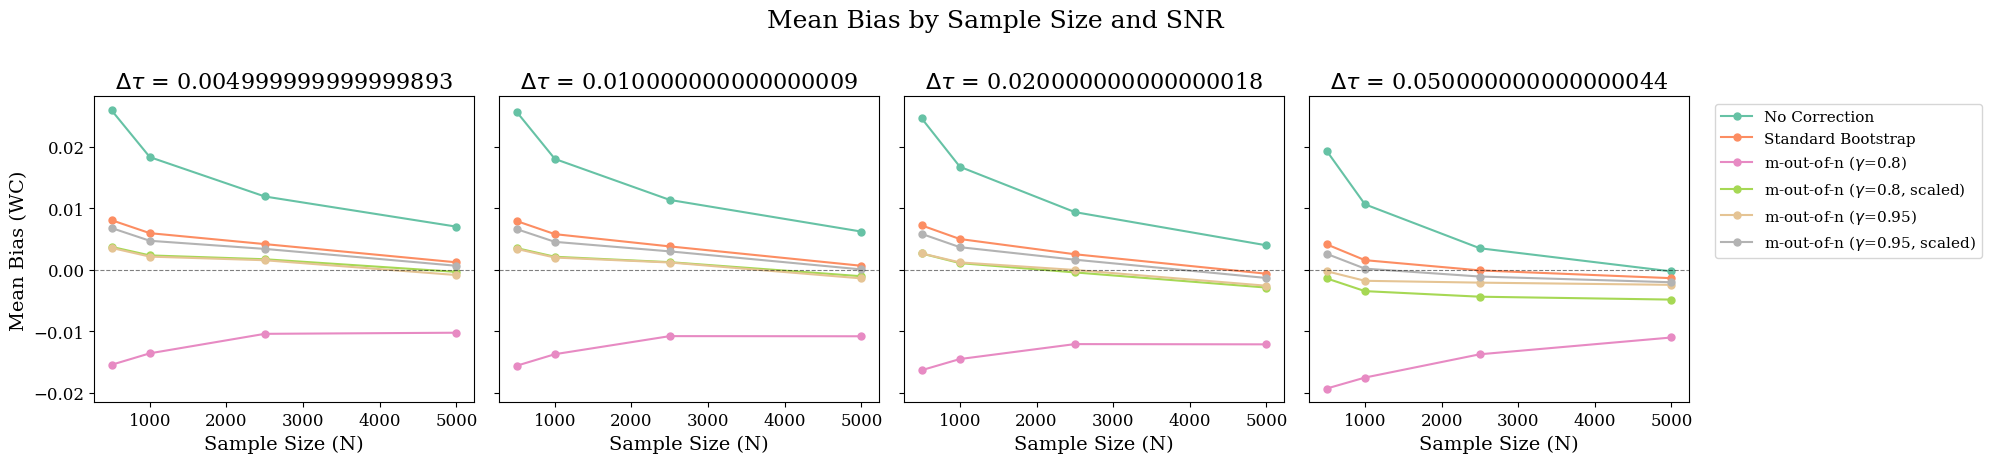

In [8]:
fig, axes = plt.subplots(1, len(tau_tuples), figsize=(5 * len(tau_tuples), 4.5), sharey=True)

for idx, tau in enumerate(tau_tuples):
    ax = axes[idx]
    delta = tau[1] - tau[0]
    for est_idx, est in enumerate(estimator_keys):
        biases = []
        for n in sample_sizes:
            res = results[(n, tau)]
            biases.append(res[f'{est}_wc_arr'].mean())
        ax.plot(sample_sizes, biases, 'o-', label=estimator_labels[est], color=colors[est_idx], markersize=5)
    
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.set_title(rf'$\Delta\tau$ = {delta}', fontsize=title_size)
    ax.set_xlabel('Sample Size (N)', fontsize=axis_label_size)
    if idx == 0:
        ax.set_ylabel('Mean Bias (WC)', fontsize=axis_label_size)
    ax.tick_params(labelsize=tick_label_size)

axes[-1].legend(fontsize=legend_label_size - 1, bbox_to_anchor=(1.05, 1), loc='upper left')
fig.suptitle('Mean Bias by Sample Size and SNR', fontsize=title_size + 2, y=1.02)
fig.tight_layout()
plt.show()

## Scaled vs Unscaled: Bias Comparison

Direct comparison of unscaled and scaled m-out-of-n at both $\gamma$ values.

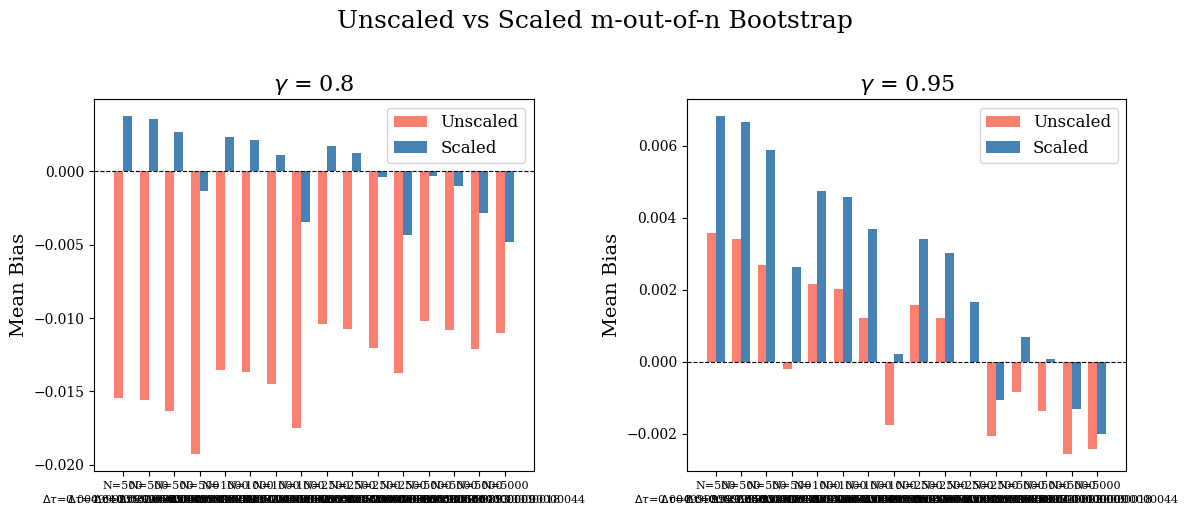

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (gamma, unscaled_key, scaled_key) in zip(axes, [
    (0.8, 'moon_080_unscaled', 'moon_080_scaled'),
    (0.95, 'moon_095_unscaled', 'moon_095_scaled'),
]):
    unscaled_biases = []
    scaled_biases = []
    labels = []
    for (n, tau) in sorted(results.keys()):
        delta = tau[1] - tau[0]
        res = results[(n, tau)]
        unscaled_biases.append(res[f'{unscaled_key}_wc_arr'].mean())
        scaled_biases.append(res[f'{scaled_key}_wc_arr'].mean())
        labels.append(f'N={n}\n$\\Delta\\tau$={delta}')
    
    x = np.arange(len(labels))
    width = 0.35
    ax.bar(x - width/2, unscaled_biases, width, label='Unscaled', color='salmon')
    ax.bar(x + width/2, scaled_biases, width, label='Scaled', color='steelblue')
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel('Mean Bias', fontsize=axis_label_size)
    ax.set_title(rf'$\gamma$ = {gamma}', fontsize=title_size)
    ax.legend(fontsize=legend_label_size)

fig.suptitle('Unscaled vs Scaled m-out-of-n Bootstrap', fontsize=title_size + 2, y=1.02)
fig.tight_layout()
plt.show()